# MSE 5720 Assignment 4
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

##### All shell scripts, original input files, and output files can be found in the GitHub repository: https://github.com/chemerzhc/Cornell-MSE5720-Assignment.
---



## Introduction

This assignment comprises a series of computational studies on calcite using density functional theory (DFT) as implemented in Quantum ESPRESSO. The work is divided into four main exercises. First, the lattice parameters and atomic positions of calcite are optimized by systematically converging the plane‑wave energy cutoff and k‑point grid, with the relaxed structure visualized using VESTA. Second, the zone‑center vibrational modes are computed via phonon dispersion calculations, and the resulting mode intensities are tabulated and compared against existing literature values. Third, the effect of structural disorder is investigated by generating five distinct displaced atomic configurations following a normal distribution of atomic positions; for each configuration, the lattice parameters and zone‑center phonon frequencies are recalculated, and the results are plotted for three different degrees of disorder. Finally, the ratios of selected vibrational mode intensities (ν₂/ν₃ and ν₄/ν₃) are computed using a provided Python script, and their correlation is analyzed graphically. Throughout, convergence criteria, output data, and comparative analyses are documented to validate the computational approach and results.

## Exercise 1: Optimization of the lattice parameters and atomic positions of calcite

### Exercise 1A

*Converge all structural parameters of calcite with respect to the plane wave cutoff and k-point grid. Compare your final converged result to both experiment and other calculations in the literature (**try to compare with results from DFT calculations that have used the same exchange-correlation functional that you have used**).*

The convergence procedure began by first testing the energy cutoff using an initial value of 20 Ry, a fixed k‑point grid of 9×9×9, and initial lattice parameters celldm(1)=12 and celldm(4)=0.5. Separately, k‑point convergence was initiated with a coarse 2×2×2 grid and a fixed cutoff of 70 Ry. Using these starting parameters, an initial vc‑relax calculation was performed to obtain structurally optimized values for celldm(1) and celldm(4) along with the atomic coordinates. These optimized cell parameters were then used in subsequent vc‑relax calculations where the energy cutoff was systematically increased. This iterative process yielded converged parameters of 70 Ry for the cutoff energy and a 6×6×6 k‑point grid, with convergence confirmed by the output message bfgs converged in 1 scf cycles and 0 bfgs steps. The final converged lattice constants *a* and *c* were derived and compared with available experimental data and prior PBE-based theoretical results.

 Energy_cutoff_Ry  celldm(1)_bohr  celldm(4)
               20         12.2045     0.7085
               30         12.1839     0.6938
               40         12.1720     0.6933
               50         12.1794     0.6926
               60         12.1691     0.6927
               70         12.1817     0.6935
               80         12.1714     0.6931
               90         12.1750     0.6935
 Energy_cutoff_Ry  Δ_celldm(1)  Δ_celldm(4)
               30       0.0206       0.0147
               40       0.0119       0.0005
               50       0.0074       0.0007
               60       0.0103       0.0001
               70       0.0126       0.0008
               80       0.0103       0.0004
               90       0.0036       0.0004


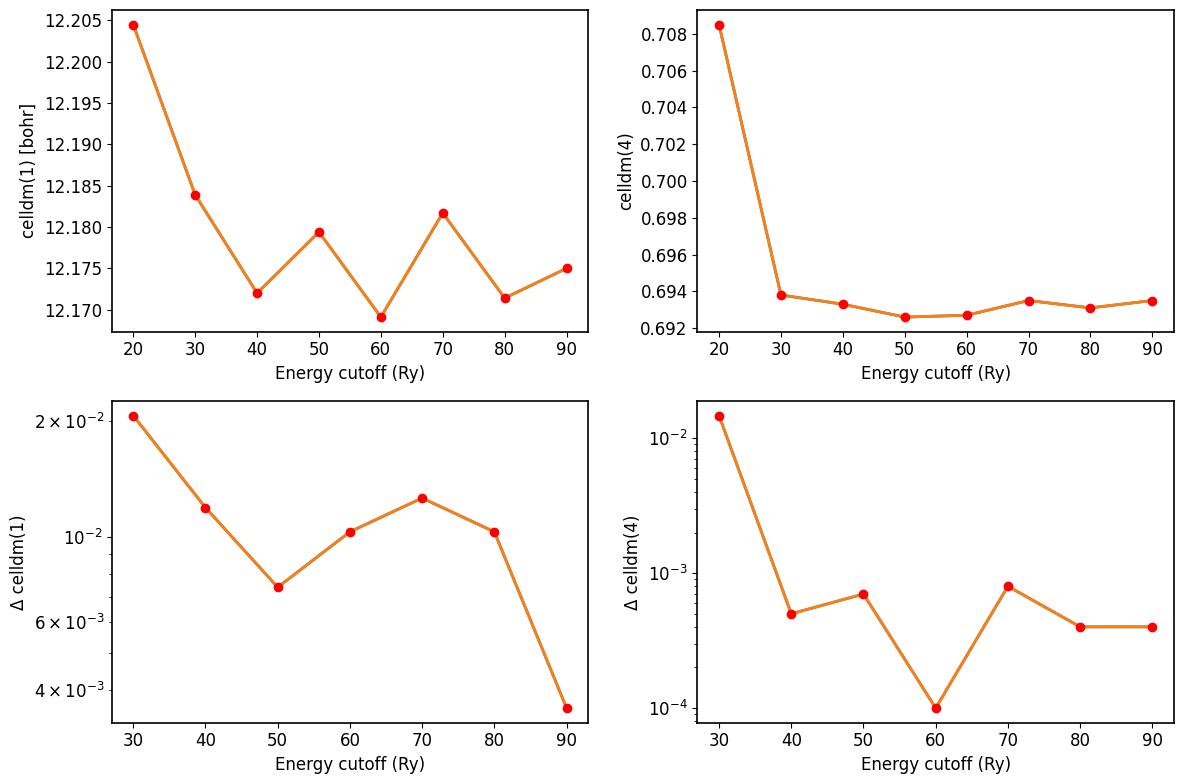

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ener_Q1_a = np.array([12.2045,12.1839,12.1720,12.1794,12.1691,12.1817,12.1714,12.1750])
ener_Q1_c = np.array([0.7085,0.6938, 0.6933,0.6926,0.6927,0.6935,0.6931,0.6935])
energy_cutoff = np.array([20,30,40,50,60,70,80,90])

a_diff = np.abs(np.diff(ener_Q1_a))
c_diff = np.abs(np.diff(ener_Q1_c))
energy_diff = energy_cutoff[1:]

table = pd.DataFrame({
    "Energy_cutoff_Ry": energy_cutoff,
    "celldm(1)_bohr": ener_Q1_a,
    "celldm(4)": ener_Q1_c
})

diff_table = pd.DataFrame({
    "Energy_cutoff_Ry": energy_diff,
    "Δ_celldm(1)": a_diff,
    "Δ_celldm(4)": c_diff
})

print(table.to_string(index=False))
print(diff_table.to_string(index=False))

plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2
})

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(energy_cutoff, ener_Q1_a)
axs[0, 0].plot(energy_cutoff, ener_Q1_a)
axs[0, 0].plot(energy_cutoff, ener_Q1_a, 'ro')
axs[0, 0].set_xlabel("Energy cutoff (Ry)")
axs[0, 0].set_ylabel("celldm(1) [bohr]")

axs[0, 1].plot(energy_cutoff, ener_Q1_c)
axs[0, 1].plot(energy_cutoff, ener_Q1_c)
axs[0, 1].plot(energy_cutoff, ener_Q1_c, 'ro')
axs[0, 1].set_xlabel("Energy cutoff (Ry)")
axs[0, 1].set_ylabel("celldm(4)")

axs[1, 0].plot(energy_diff, a_diff)
axs[1, 0].plot(energy_diff, a_diff)
axs[1, 0].plot(energy_diff, a_diff, 'ro')
axs[1, 0].set_yscale("log")
axs[1, 0].set_xlabel("Energy cutoff (Ry)")
axs[1, 0].set_ylabel("Δ celldm(1)")

axs[1, 1].plot(energy_diff, c_diff)
axs[1, 1].plot(energy_diff, c_diff)
axs[1, 1].plot(energy_diff, c_diff, 'ro')
axs[1, 1].set_yscale("log")
axs[1, 1].set_xlabel("Energy cutoff (Ry)")
axs[1, 1].set_ylabel("Δ celldm(4)")

plt.tight_layout()
plt.show()


From the above figures, it can be seen that at 70 Ry both cell parameters remain stable, exhibiting minimal fluctuation.

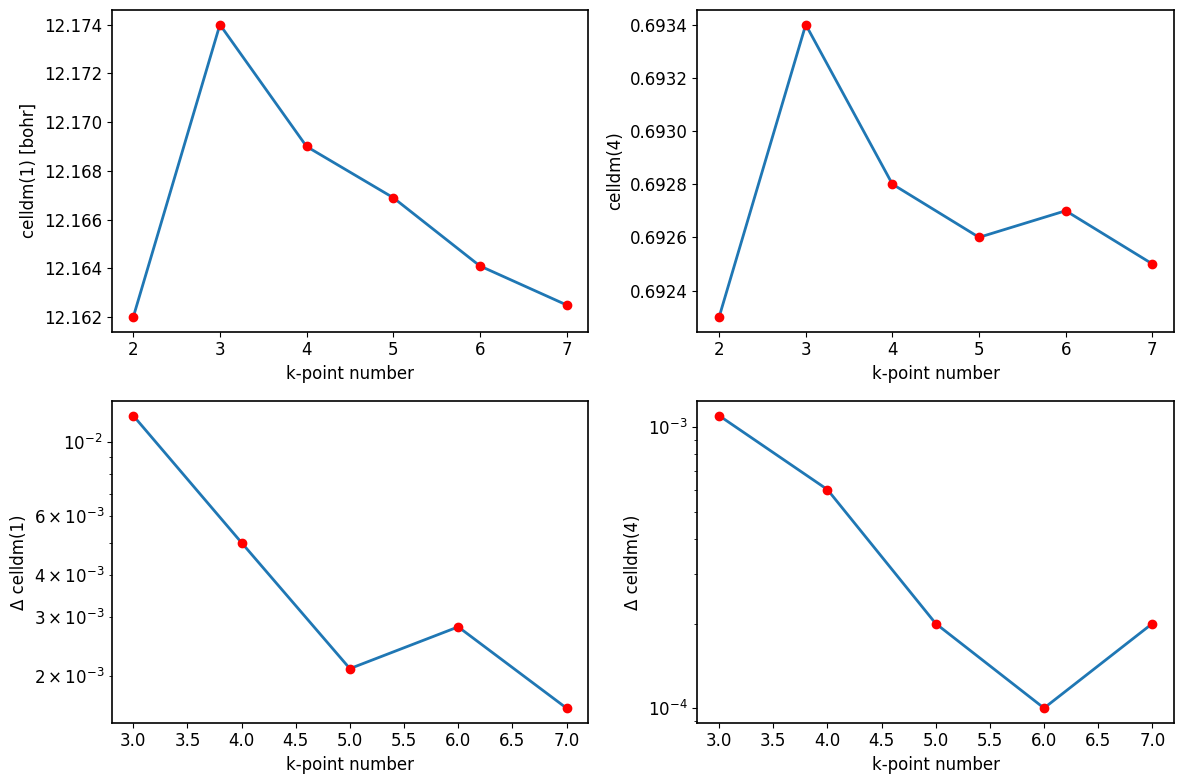

In [10]:
k_Q1_a = np.array([12.1620,12.1740,12.1690,12.1669,12.1641,12.1625])
k_Q1_c = np.array([0.6923,0.6934,0.6928,0.6926,0.6927,0.6925])

k_point = np.array([2,3,4,5,6,7])
k_point_diff = k_point[1:]

a_diff_k = np.abs(np.diff(k_Q1_a))
c_diff_k = np.abs(np.diff(k_Q1_c))

plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2
})

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(k_point, k_Q1_a)
axs[0, 0].plot(k_point, k_Q1_a, 'ro')
axs[0, 0].set_xlabel("k-point number")
axs[0, 0].set_ylabel("celldm(1) [bohr]")

axs[0, 1].plot(k_point, k_Q1_c)
axs[0, 1].plot(k_point, k_Q1_c, 'ro')
axs[0, 1].set_xlabel("k-point number")
axs[0, 1].set_ylabel("celldm(4)")

axs[1, 0].plot(k_point_diff, a_diff_k)
axs[1, 0].plot(k_point_diff, a_diff_k, 'ro')
axs[1, 0].set_yscale("log")
axs[1, 0].set_xlabel("k-point number")
axs[1, 0].set_ylabel("Δ celldm(1)")

axs[1, 1].plot(k_point_diff, c_diff_k)
axs[1, 1].plot(k_point_diff, c_diff_k, 'ro')
axs[1, 1].set_yscale("log")
axs[1, 1].set_xlabel("k-point number")
axs[1, 1].set_ylabel("Δ celldm(4)")

plt.tight_layout()
plt.show()


From the above figures, it can be observed that at 6 k-points, both cell parameters also exhibit relatively low fluctuations.

To show that 70 Ry and k points of 6 are indeed the converged parameters, verification are conducted based on the output files.

Comparing with literature values from both experiments [2] and PBE DFT computations [5], the optimized values show good accuracy, with relative errors of 0.528% and 1.724%, and 0.149% and 0.889%, for experiments and DFT computations for $a$ and $c$, respectively.

In [27]:
import pandas as pd

df_lattice = pd.DataFrame({
    '': ['a', 'c'],
    'Calculated': [5.04649, 17.24727],
    'Ref [2]': [5.020, 16.955],
    'Ref [5]': [5.039, 17.402]
})

display(df_lattice)


,,Calculated,Ref [2],Ref [5]
0,a,5.04649,5.020,5.039
1,c,17.24727,16.955,17.402


### Exercise 1B 
*Use VESTA to visualize the structure of calcite and include an image in your report. A well-presented crystal structure makes the main structural features (important bonds, coordination environments) clear.*

The $\tt.cif$ file was generated using the data generated from Quantum ESPRESSO.

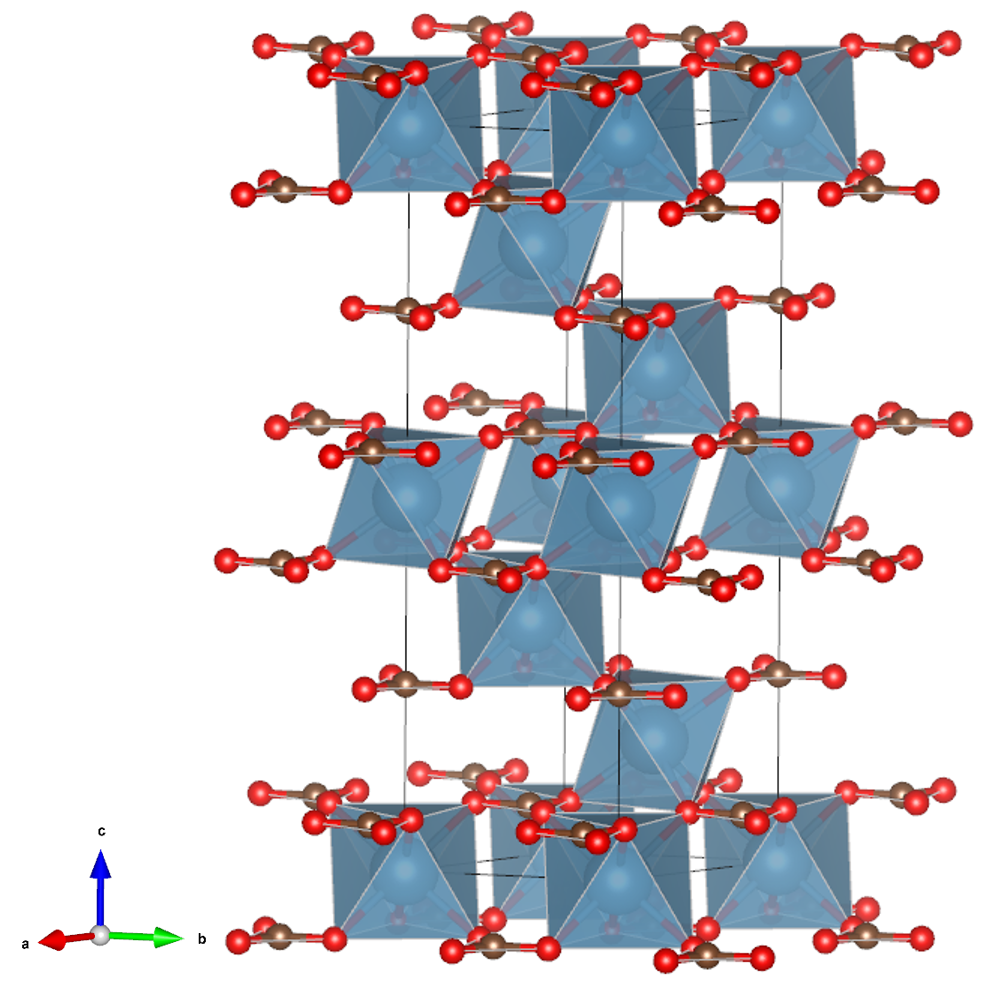

## Exercise 2: Calculation of zone-center vibrational modes of calcite

### Exercise 2A
*Calculate the zone-center vibrational modes for your fully converged and relaxed calcite structure from 1A above, with LO-TO splitting taken into account; perform one calculation with a slightly higher plane wave cutoff and denser k-point grid to ensure that the frequencies are converged.*

The zone-center vibrational modes were calculated from the general calculation of lattice dynamics. A $\tt scf$ calculation is performed first, following a phonon calculation. From the output file of the postprocessing and taking the hint from the homework instructions, the modes were identified as 22, 23, and 27, respectively. The values compared with experimental results are listed in the following table. From the compared results, one conclude that the relative errors $\nu_2$, $\nu_3$ and $\nu_4$ compared with experimental values are 0.4742%, 0.2183%, and 0.0043%, respectively.

In [23]:
import numpy as np
import pandas as pd

modes = [22, 23, 27]
nomina = ['ν2', 'ν3', 'ν4']
frequency = np.array([686.52, 830.53, 1379.56])
ref_freq = [683.27954, 828.72124, 1379.50005]
intensity = [0.318, 2.769, 69.3211]

df_modes = pd.DataFrame({
    '': nomina,
    'Modes': modes,
    'Intensity': intensity,
    'Computed Frequency (cm-1': frequency,
    'Ref[6] (cm-1)': ref_freq
})

display(df_modes)


,,Modes,Intensity,Computed Frequency (cm-1,Ref[6] (cm-1)
0,ν2,22,0.3180,686.52,683.27954
1,ν3,23,2.7690,830.53,828.72124
2,ν4,27,69.3211,1379.56,1379.50005


## Exercise 3: Generation of disordered structures


### Exercise 3A
*Using your fully relaxed structure from above, generate a series of 5 structures with different rhombohedral angles. Select your angles randomly from a Gaussian distribution having a mean of your fully relaxed angle and a standard deviation. Modify the lattice parameter to keep the volume constant.*

In [53]:
import numpy as np

np.random.seed(42)

mean_angle = 5.00
std_angle  = 0.2

angles_deg = np.random.normal(
    loc=mean_angle,
    scale=std_angle,
    size=5
)



Convert those disordered angles into $\tt rad$ and compute the corresponding ```celldm(1)``` and ```celldm(4)```, based on the given equation 

$$
V = a^3 (1 - \cos\gamma ) \times \sqrt{(1+2\cos\gamma)} 
$$

The five correponding cell parameters are listed in the following table:



In [50]:
import pandas as pd

para = ['celldm(1)', 'celldm(4)']
val1 = [11.3568, 0.6092]
val2 = [11.3568, 0.6390]
val3 = [11.8795, 0.6671]
val4 = [11.7517, 0.6542]
val5 = [11.6303, 0.6413]

tab_kp = pd.DataFrame({
    'Cell parameters': para,
    'Structure 1': val1,
    'Structure 2': val2,
    'Structure 3': val3,
    'Structure 4': val4,
    'Structure 5': val5
})

tab_kp


,Cell parameters,Structure 1,Structure 2,Structure 3,Structure 4,Structure 5
0,celldm(1),11.3568,11.3568,11.8795,11.7517,11.6303
1,celldm(4),0.6092,0.6390,0.6671,0.6542,0.6413


### Exercise 3B
*Calculate the frequencies of the phonons at the zone center for your distorted structures using the procedure described above.*

The values of the five different calculated frequencies and intensities correpsonding to their modes are listed in the following table.

In [49]:
modes = [22, 23, 27]

frequency1 = np.array([675.63, 823.12, 1347.07])
frequency2 = np.array([693.51, 824.08, 1389.95])
frequency3 = np.array([682.64, 828.2, 1365.34])
frequency4 = np.array([681.04, 826.8, 1361.44])
frequency5 = np.array([679.48, 825.55, 1357.46])

intensity1 = [0.1656, 2.3151, 71.5828]
intensity2 = [0.3875, 2.9795, 71.427]
intensity3 = [0.25, 2.6683, 70.0238]
intensity4 = [0.2278, 2.6044, 70.4025]
intensity5 = [0.208, 2.5319, 70.7662]

# 创建 DataFrame
tab_q = pd.DataFrame({
    'Modes': modes,
    'Frequency (I)': frequency1,
    'Intensity (I)': intensity1,
    'Frequency (II)': frequency2,
    'Intensity (II)': intensity2,
    'Frequency (III)': frequency3,
    'Intensity (III)': intensity3,
    'Frequency (IV)': frequency4,
    'Intensity (IV)': intensity4,
    'Frequency (V)': frequency5,
    'Intensity (V)': intensity5
})

tab_q


,Modes,Frequency (I),Intensity (I),Frequency (II),Intensity (II),Frequency (III),Intensity (III),Frequency (IV),Intensity (IV),Frequency (V),Intensity (V)
0,22,675.63,0.1656,693.51,0.3875,682.64,0.2500,681.04,0.2278,679.48,0.2080
1,23,823.12,2.3151,824.08,2.9795,828.20,2.6683,826.80,2.6044,825.55,2.5319
2,27,1347.07,71.5828,1389.95,71.4270,1365.34,70.0238,1361.44,70.4025,1357.46,70.7662


### Exercise 3C
*Using your own data as well as your classmates’, plot the frequencies of the above mentioned modes (involving the $\rm CO_3$ units) as a function of the rhombohedral angle $\gamma$.*

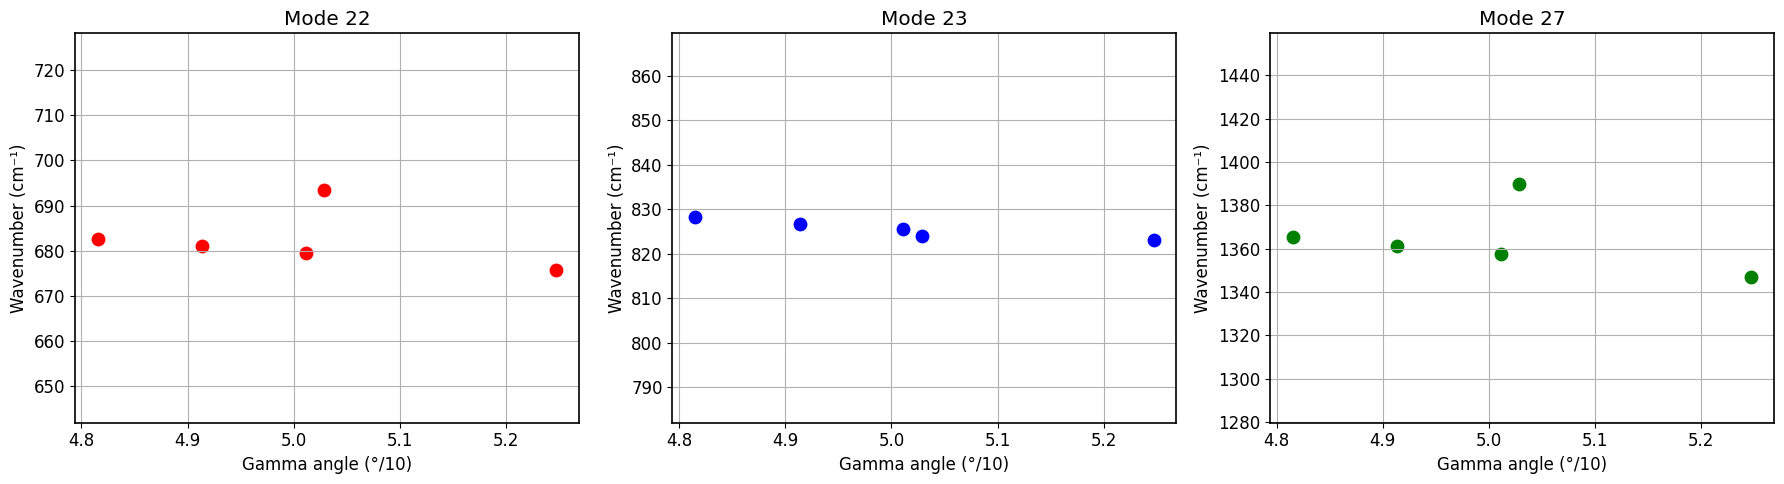

In [60]:
import numpy as np
import matplotlib.pyplot as plt

gamma = np.array([52.46819631, 50.28640894, 48.15392881, 49.13810641, 50.11269536]) / 10

frequency1 = np.array([675.63, 823.12, 1347.07])
frequency2 = np.array([693.51, 824.08, 1389.95])
frequency3 = np.array([682.64, 828.2, 1365.34])
frequency4 = np.array([681.04, 826.8, 1361.44])
frequency5 = np.array([679.48, 825.55, 1357.46])

frequencies = np.column_stack([frequency1, frequency2, frequency3, frequency4, frequency5])

modes = [22, 23, 27]
colors = ['red', 'blue', 'green']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ax in enumerate(axes):
    freq = frequencies[i]
    sort_idx = np.argsort(-freq)
    sorted_gamma = gamma[sort_idx]
    sorted_freq = freq[sort_idx]
    
    ax.scatter(sorted_gamma, sorted_freq, color=colors[i], s=80)
    ax.set_xlabel('Gamma angle (°/10)')
    ax.set_ylabel('Wavenumber (cm⁻¹)')
    ax.set_title(f'Mode {modes[i]}')
    ax.grid(True)
    ax.set_ylim(sorted_freq.min()*0.95, sorted_freq.max()*1.05)

plt.tight_layout()
plt.show()


From the plotted figure, one can observe that the data is distributed in a cross-shaped layout, with larger angles of disordered structures having more sparsely distributed points.

## Exercise 4: Comparison of mode intensities between distorted structures

### Exercise 4A
*Use the python script provided to obtain the intensity of the calculated phonon modes for all disordered structures and your fully relaxed perfectly ordered structure. This script calculates the oscillator strength for each mode, which depends on the Born effective charges and phonon eigenvectors. Calculate the ratio of peak intensities for $\nu_2/\nu_3$ and $\nu_4/\nu_3$. You can use arbitrary scaling.*

By running the provided python script for postprocessing the results generated from the phonon calculation, one can compute the intensities corresponding to different frequencies based on ```diel_output.txt```. By plot the curves one can obtain the values of $\nu_2 / \nu_3$ and $\nu_4/\nu_3$ as follows:

In [62]:
import pandas as pd

nomina = ['ν2', 'ν3', 'ν4']

freq1 = [823.084, 1347.05, 674.983]
freq2 = [824.037, 1389.96, 691.874]
freq3 = [828.077, 1365.37, 681.637]
freq4 = [826.815, 1361.48, 680.007]
freq5 = [825.517, 1357.54, 678.559]
tab_q4 = pd.DataFrame({
    '': nomina,
    'Structure I': freq1,
    'Structure II': freq2,
    'Structure III': freq3,
    'Structure IV': freq4,
    'Structure V': freq5
})

tab_q4


,,Structure I,Structure II,Structure III,Structure IV,Structure V
0,ν2,823.084,824.037,828.077,826.815,825.517
1,ν3,1347.050,1389.960,1365.370,1361.480,1357.540
2,ν4,674.983,691.874,681.637,680.007,678.559


Based on the computed values, we can hence obtain the values for $\nu_2/\nu_3$ and $\nu_4/\nu_3$:


In [64]:
nomina_new = ['ν2/ν3', 'ν4/ν3']

freq1_new = [823.084/1347.05, 674.983/1347.05]
freq2_new = [824.037/1389.96, 691.874/1389.96]
freq3_new = [828.077/1365.37, 681.637/1365.37]
freq4_new = [826.815/1361.48, 680.007/1361.48]
freq5_new = [825.517/1357.54, 678.559/1357.54]
freq0_new = [830.714/1379.73, 685.179/1379.73]

tab_q4_2 = pd.DataFrame({
    '': nomina_new,
    'Relaxed Structure': freq0_new,
    'Structure I': freq1_new,
    'Structure II': freq2_new,
    'Structure III': freq3_new,
    'Structure IV': freq4_new,
    'Structure V': freq5_new
})

tab_q4_2


,,Relaxed Structure,Structure I,Structure II,Structure III,Structure IV,Structure V
0,ν2/ν3,0.602084,0.611027,0.592849,0.606485,0.607291,0.608098
1,ν4/ν3,0.496604,0.501082,0.497765,0.499232,0.499462,0.499845


### Exercise 4B
*Plot the ratio $\nu_2/\nu_3$ (y-axis) against the ratio $\nu_4/\nu_3$. What can you say about the relationship between these ratios and the degree of disorder in the crystal?*

Text(0, 0.5, '$ν_2/ν_3$')

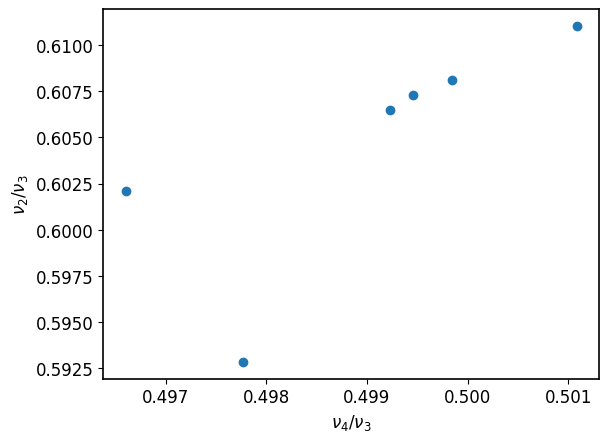

In [66]:
y_axis = [freq0_new[0],freq1_new[0],freq2_new[0],freq3_new[0],freq4_new[0],freq5_new[0]]
x_axis = [freq0_new[1],freq1_new[1],freq2_new[1],freq3_new[1],freq4_new[1],freq5_new[1]]
plt.scatter(x_axis,y_axis)
plt.xlabel('$ν_4/ν_3$')
plt.ylabel('$ν_2/ν_3$')

Based on the computed $\nu_2$, $\nu_3$, and $\nu_4$ from exercise 3, we obtained the values used for the figure above. From plotting the disordered structures generated from the Gaussian distribution, it can be observed that as $\nu_4/\nu_3$ increases, $\nu_2/\nu_3$ also increases, indicating a positive correlation between the two ratios. While structure 2 shows a minor deviation from the general trend, the overall positive correlation is clearly evident.

## Summary

In this homework, I successfully combined various techniques learned previously to compute the properties of calcite. Applying the theoretical knowledge from lectures directly to practical calculations in Quantum ESPRESSO helped me gain a deeper understanding of first-principles calculations, structural optimization, and vibrational properties. In particular, exercises involving the generation of disordered structures and the analysis of vibrational modes ($\nu_2$, $\nu_3$, and $\nu_4$) strengthened my comprehension of how structural variations influence vibrational frequencies and intensities. Overall, this assignment provided a valuable opportunity to integrate lecture concepts with hands-on computational practice, enhancing both my technical skills and conceptual understanding of materials modeling.

## References

[1] Andersson, M., Dideriksen, K., Sakuma, H. et al. Modelling how incorporation of divalent cations affects calcite wettability–implications for biomineralisation and oil recovery. Sci Rep 6, 28854 (2016). [10.1038/srep28854](https://doi.org/10.1038/srep28854).

[2] S. A. Markgraf, Richard J. Reeder; High-temperature structure refinements of calcite and magnesite. American Mineralogist 1985;; 70 (5-6): 590–600. [0003-004X/85/0506-0590$02.00](http://www.minsocam.org/ammin/AM70/AM70_590.pdf)

[3] Leo Merrill and William A. Bassett , "Miniature diamond anvil pressure cell for single crystal x‐ray diffraction studies", Review of Scientific Instruments 45, 290-294 (1974) [10.1063/1.1686607](https://doi.org/10.1063/1.1686607).

[4] Joseph R. Smyth, Thomas J. Ahrens. The crystal structure of calcite III. Geophysical Research Letters, Vol. 24, No. 13, P. 1595-1598, [10.1029/97GL01603](https://agupubs.onlinelibrary.wiley.com/doi/abs/10.1029/97GL01603)

[5] Ulian, G., Valdrè, G. Study of the variation of the optical properties of calcite with applied stress, useful for specific rock and material mechanics. Sci Rep 12, 299 (2022). [10.1038/s41598-021-04471-6](https://doi.org/10.1038/s41598-021-04471-6)

[6] Cheng-Lu Jiang, Wei Zeng, Fu-Sheng Liu, Bin Tang, Qi-Jun Liu. First-principles analysis of vibrational modes of calcite, magnesite and dolomite. Journal of Physics and Chemistry of Solids. Vol. 131, Aug. 2019, P 1-9. [10.1016/j.jpcs.2019.03.011](https://doi.org/10.1016/j.jpcs.2019.03.011)